# TQ-IoT: Tabular Multi-Objective RL — Real FIT IoT-Lab Data
**Authors:** Abhay Singh & Peeyush Kelkar  
**Stockholm University — Spring 2026**

---

### What this notebook does
1. Loads real FIT IoT-Lab sensor data and power logs
2. Builds a clean per-step dataset
3. Trains TQ-IoT using tabular Q-learning + Chebyshev scalarisation
4. Evaluates 11 weight configurations and 3 baselines
5. Plots Pareto front, AoI curve, lifetime curve

### Expected folder structure
```
THESIS-IOT-SCHEDULING-/
├── notebooks/
│   └── this_notebook.ipynb
├── data/
│   ├── processed/          ← created automatically
│   └── raw/
│       └── exp_436032/
│           ├── exp_436032_sensor_stream_raw.txt
│           └── consumption/
│               ├── m3_10.oml
│               ├── m3_11.oml
│               ├── m3_12.oml
│               ├── m3_13.oml
│               └── m3_14.oml
└── results/                ← created automatically
```


## 1. Imports and Setup

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Tuple, List, Dict

# create output folders if they don't exist
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../results", exist_ok=True)

print("Libraries loaded.")
print("Output folders ready.")


Libraries loaded.
Output folders ready.


## 2. File Paths

In [2]:
# paths are relative to the notebooks/ folder
# ../  means go up one level to the project root

SENSOR_FILE = "../data/raw/exp_436032/exp_436032_sensor_stream_raw.txt"

OML_FILES = {
    "m3-10": "../data/raw/exp_436032/consumption/m3_10.oml",
    "m3-11": "../data/raw/exp_436032/consumption/m3_11.oml",
    "m3-12": "../data/raw/exp_436032/consumption/m3_12.oml",
    "m3-13": "../data/raw/exp_436032/consumption/m3_13.oml",
    "m3-14": "../data/raw/exp_436032/consumption/m3_14.oml",
}

CLEAN_CSV   = "../data/processed/fit_iot_clean.csv"
RESULTS_CSV = "../results/tq_iot_aoi_results.csv"

print("File paths set.")


File paths set.


## 3. Parse FIT IoT-Lab Sensor Stream

Raw line format:
```
1776012342.562994;m3-10;Chip temperature measure: 3.01E1
1776012342.563410;m3-10;cmd > Luminosity measure: 4.8828125E-1 lux
1776012342.563615;m3-10;cmd > Pressure measure: 9.983738E2 mabar
```
We parse all three sensors per node into a tidy long-format DataFrame.


In [3]:
def parse_sensor_stream(path: str) -> pd.DataFrame:
    """
    Parse the raw FIT IoT-Lab serial log.
    Returns one row per sensor reading:
        timestamp, node_id, sensor_type, value
    Scientific notation (e.g. 3.01E1) is handled automatically by float().
    """
    records = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split(';')
            if len(parts) < 3:
                continue
            try:
                ts   = float(parts[0])
                node = parts[1].strip()
                raw  = parts[2].strip().replace('cmd >', '').strip()
            except ValueError:
                continue
            if not raw:
                continue

            if 'Chip temperature' in raw:
                stype = 'temperature'
                val   = raw.split(':')[1].strip()
            elif 'Luminosity' in raw:
                stype = 'luminosity'
                val   = raw.split(':')[1].strip().split('lux')[0]
            elif 'Pressure' in raw:
                stype = 'pressure'
                val   = raw.split(':')[1].strip().split('mabar')[0]
            else:
                continue

            try:
                records.append({
                    'timestamp'  : ts,
                    'node_id'    : node,
                    'sensor_type': stype,
                    'value'      : float(val),
                })
            except ValueError:
                continue

    df = pd.DataFrame(records)
    df = df.sort_values(['timestamp', 'node_id']).reset_index(drop=True)
    return df


raw_df = parse_sensor_stream(SENSOR_FILE)

print(f"Total sensor readings : {len(raw_df):,}")
print(f"Nodes found           : {sorted(raw_df['node_id'].unique())}")
print(f"Sensor types          : {raw_df['sensor_type'].unique().tolist()}")
print(f"Duration              : {raw_df['timestamp'].max() - raw_df['timestamp'].min():.0f} seconds")
raw_df.head(9)


Total sensor readings : 2,505
Nodes found           : ['m3-10', 'm3-11', 'm3-12', 'm3-13', 'm3-14']
Sensor types          : ['temperature', 'luminosity', 'pressure']
Duration              : 830 seconds


,timestamp,node_id,sensor_type,value
0,1.776012e+09,m3-10,temperature,30.100000
1,1.776012e+09,m3-10,luminosity,0.488281
2,1.776012e+09,m3-10,pressure,998.373800
3,1.776012e+09,m3-11,temperature,29.943750
4,1.776012e+09,m3-11,luminosity,0.732422
5,1.776012e+09,m3-11,pressure,999.052730
6,1.776012e+09,m3-12,temperature,30.095833
7,1.776012e+09,m3-12,luminosity,0.488281
8,1.776012e+09,m3-12,pressure,998.150630


## 4. Build Clean Per-Step DataFrame

Pivot the long-format readings into one row per (node, step).  
Temperature timestamps (~5 s cadence) anchor each step.  
Luminosity and pressure are matched within ±1 second of each temperature reading.

Saved to: `data/processed/fit_iot_clean.csv`


In [4]:
def build_clean_dataframe(raw_df: pd.DataFrame) -> pd.DataFrame:
    """
    Pivot raw readings into one row per (node_id, step).
    Columns: timestamp, node_id, temperature, luminosity, pressure
    """
    nodes    = sorted(raw_df['node_id'].unique())
    all_rows = []

    for node in nodes:
        ndf   = raw_df[raw_df['node_id'] == node]
        temps = (ndf[ndf['sensor_type'] == 'temperature']
                 .sort_values('timestamp').reset_index(drop=True))

        for _, row in temps.iterrows():
            ts = row['timestamp']

            def closest(stype):
                sub = ndf[
                    (ndf['sensor_type'] == stype) &
                    (ndf['timestamp'] >= ts - 1.0) &
                    (ndf['timestamp'] <= ts + 1.0)
                ]
                if len(sub) == 0:
                    return np.nan
                return sub.loc[(sub['timestamp'] - ts).abs().idxmin(), 'value']

            all_rows.append({
                'timestamp'  : ts,
                'node_id'    : node,
                'temperature': round(float(row['value']), 4),
                'luminosity' : round(float(closest('luminosity')), 4),
                'pressure'   : round(float(closest('pressure')), 4),
            })

    clean = (pd.DataFrame(all_rows)
             .sort_values(['timestamp', 'node_id'])
             .reset_index(drop=True))
    return clean


clean_df = build_clean_dataframe(raw_df)
clean_df.to_csv(CLEAN_CSV, index=False)

print(f"Clean rows   : {len(clean_df)}")
print(f"Nodes        : {clean_df['node_id'].nunique()}")
print(f"Saved to     : {CLEAN_CSV}")
clean_df.head(10)


Clean rows   : 835
Nodes        : 5
Saved to     : ../data/processed/fit_iot_clean.csv


,timestamp,node_id,temperature,luminosity,pressure
0,1.776012e+09,m3-10,30.1000,0.4883,998.3738
1,1.776012e+09,m3-11,29.9438,0.7324,999.0527
2,1.776012e+09,m3-12,30.0958,0.4883,998.1506
3,1.776012e+09,m3-13,28.8292,0.4883,999.2073
4,1.776012e+09,m3-14,30.0000,0.4883,997.8311
5,1.776012e+09,m3-12,30.0958,0.2441,998.1941
6,1.776012e+09,m3-13,28.8292,0.2441,999.2651
7,1.776012e+09,m3-14,30.0000,0.2441,997.8018
8,1.776012e+09,m3-10,30.1000,0.2441,998.2454
9,1.776012e+09,m3-11,29.9438,0.4883,999.1604


## 5. FITIoTDataFeed

Replaces the random sensor generation in the original notebook.

At every environment step `feed.next()` returns the next **real** sensor reading.  
The stream advances regardless of the action taken — even when the agent sleeps,  
time moves forward through the recorded data.  
AoI only resets when the agent transmits successfully.


In [6]:
class FITIoTDataFeed:
    """
    Streams real FIT IoT-Lab sensor values into the RL environment.

    Replaces:
        self.sensed_value = self.np_rng.normal(...)    # original fake generation

    With:
        temp, lux, pressure = self.feed.next()         # real recorded values
    """

    def __init__(self, df: pd.DataFrame, node_id: str = 'm3-10'):
        node_df           = df[df['node_id'] == node_id].reset_index(drop=True)
        self.timestamps   = node_df['timestamp'].values
        self.temperatures = node_df['temperature'].values
        self.luminosities = node_df['luminosity'].values
        self.pressures    = node_df['pressure'].values
        self.n            = len(node_df)
        self.node_id      = node_id
        self.idx          = 0

    def reset(self):
        self.idx = 0

    def next(self) -> Tuple[float, float, float]:
        """Return next real reading. Cycles when stream is exhausted."""
        i = self.idx % self.n
        vals = (
            float(self.temperatures[i]),
            float(self.luminosities[i]),
            float(self.pressures[i]),
        )
        self.idx += 1
        return vals

    def __len__(self):
        return self.n


# sanity check
feed_test = FITIoTDataFeed(clean_df, node_id='m3-10')
feed_test.reset()
print("First 5 real sensor readings for m3-10:")
print(f"{'Step':<6} {'Temp (C)':<12} {'Lux':<12} {'Pressure (mbar)'}")
for i in range(5):
    t, lx, p = feed_test.next()
    print(f"{i:<6} {t:<12.4f} {lx:<12.4f} {p:.4f}")


First 5 real sensor readings for m3-10:
Step   Temp (C)     Lux          Pressure (mbar)
0      30.1000      0.4883       998.3738
1      30.1000      0.2441       998.2454
2      30.0771      0.4883       998.4846
3      30.1479      0.2441       998.4441
4      30.1271      0.4883       998.2256


## 6. Environment and Agent Configuration

In [7]:
@dataclass
class EnvConfig:
    battery_cap       : int   = 100
    energy_cost_sleep : int   = 1      # sleep    → 1 unit
    energy_cost_sense : int   = 5      # wait     → 5 units
    energy_cost_tx    : int   = 10     # transmit → 10 units
    tx_success_prob   : float = 0.90
    aoi_cap           : int   = 20
    horizon           : int   = 200
    channel_trans     : np.ndarray = field(default_factory=lambda: np.array([
        [0.80, 0.15, 0.05],
        [0.10, 0.75, 0.15],
        [0.05, 0.20, 0.75],
    ], dtype=float))


@dataclass
class AgentConfig:
    gamma                 : float = 0.95
    alpha                 : float = 0.2
    epsilon_start         : float = 0.25
    epsilon_end           : float = 0.05
    epsilon_decay_episodes: int   = 300
    weights: List[Tuple[float, float]] = field(
        default_factory=lambda: [
            (round(w, 1), round(1 - w, 1))
            for w in np.linspace(0.0, 1.0, 11)
        ])


print("EnvConfig and AgentConfig defined.")


EnvConfig and AgentConfig defined.


## 7. TQIoTEnv — RL Environment with Real Sensor Data

**State:** `(battery_bin, aoi_bin, delta_v_bin, channel_bin)` — 270 states  
**Actions:** 0 = sleep, 1 = wait, 2 = transmit  
**Rewards:** `r_E = -cost/10`  and  `r_F = -aoi/aoi_cap`

Key change from original:
- `feed.next()` is called every step regardless of action
- `delta_v` is computed from the **real** temperature change, not a random value
- AoI resets only on successful transmit


In [8]:
N_BATTERY = 6
N_AOI     = 5
N_DELTA_V = 3
N_CHANNEL = 3
N_ACTIONS = 3
N_STATES  = N_BATTERY * N_AOI * N_DELTA_V * N_CHANNEL   # 270


def state_to_index(s: Tuple[int, int, int, int]) -> int:
    bb, ab, dvb, ch = s
    return ((bb * N_AOI + ab) * N_DELTA_V + dvb) * N_CHANNEL + ch


class TQIoTEnv:
    """
    IoT scheduling environment driven by real FIT IoT-Lab sensor data.

    FIT IoT-Lab integration points (marked with # FIT):
        - feed.next() called every step → real temp, lux, pressure
        - delta_v computed from real temperature delta
        - AoI resets only when agent transmits successfully
    """

    def __init__(self, cfg: EnvConfig, feed: FITIoTDataFeed, seed: int = 0):
        self.cfg  = cfg
        self.feed = feed
        self.rng  = np.random.default_rng(seed)

    def _battery_bin(self, b):
        if b > 80: return 5
        elif b > 60: return 4
        elif b > 40: return 3
        elif b > 20: return 2
        elif b > 5:  return 1
        else:        return 0

    def _aoi_bin(self, a):
        if a <= 1:    return 0
        elif a <= 4:  return 1
        elif a <= 8:  return 2
        elif a <= 12: return 3
        else:         return 4

    def _delta_v_bin(self, delta: float) -> int:
        # FIT: bins the real temperature change since last step
        if delta < 0.2:   return 0
        elif delta < 0.5: return 1
        else:             return 2

    def _obs(self):
        return (
            self._battery_bin(self.battery),
            self._aoi_bin(self.aoi),
            self._delta_v_bin(self.delta_v),
            self.channel,
        )

    def reset(self):
        self.battery = self.cfg.battery_cap
        self.aoi     = 1
        self.channel = int(self.rng.choice([0, 1, 2], p=[0.3, 0.4, 0.3]))
        self.t       = 0

        # FIT: reset the real data stream to the beginning
        self.feed.reset()
        self.temperature, self.luminosity, self.pressure = self.feed.next()
        self.prev_temperature = self.temperature
        self.delta_v          = 0.0

        return self._obs()

    def step(self, action: int):
        cfg = self.cfg

        # FIT: advance the real sensor stream every step (even during sleep)
        self.prev_temperature = self.temperature
        self.temperature, self.luminosity, self.pressure = self.feed.next()
        self.delta_v = abs(self.temperature - self.prev_temperature)

        # energy cost
        cost = {0: cfg.energy_cost_sleep,
                1: cfg.energy_cost_sense,
                2: cfg.energy_cost_tx}[action]

        if self.battery < cost:
            return self._obs(), (-self.battery / 10.0, -self.aoi / cfg.aoi_cap), True, {}

        self.battery -= cost

        # AoI update — only resets on successful transmit
        if action == 2 and self.channel >= 1:
            if self.rng.random() < cfg.tx_success_prob:
                self.aoi = 1
            else:
                self.aoi = min(self.aoi + 1, cfg.aoi_cap)
        else:
            self.aoi = min(self.aoi + 1, cfg.aoi_cap)

        # channel evolves via Markov chain
        self.channel = int(np.argmax(
            self.rng.multinomial(1, cfg.channel_trans[self.channel])))

        r_E  = -cost / 10.0
        r_F  = -self.aoi / cfg.aoi_cap
        self.t += 1
        done = (self.battery <= 0 or self.t >= cfg.horizon)

        return self._obs(), (r_E, r_F), done, {
            'temperature': self.temperature,
            'luminosity' : self.luminosity,
            'pressure'   : self.pressure,
            'delta_v'    : self.delta_v,
        }


print(f"TQIoTEnv defined.  State space: {N_STATES}  Actions: {N_ACTIONS}")


TQIoTEnv defined.  State space: 270  Actions: 3


## 8. Agent — Two Q-Tables + Chebyshev Scalarisation

**QE** learns energy-optimal behaviour.  
**QF** learns freshness-optimal behaviour.  

At decision time, Chebyshev scalarisation combines both:

```
score(a) = -max( wE * |QE(s,a) - z*E|,  wF * |QF(s,a) - z*F| )
```

Pick the action with the **highest score**.


In [9]:
class TabularMORLAgent:

    def __init__(self, cfg: AgentConfig = AgentConfig(), seed: int = 0):
        self.cfg = cfg
        self.rng = random.Random(seed)
        self.QE  = np.zeros((N_STATES, N_ACTIONS))   # energy Q-table
        self.QF  = np.zeros((N_STATES, N_ACTIONS))   # freshness Q-table
        self.ep  = 0

    def epsilon(self):
        e0, e1 = self.cfg.epsilon_start, self.cfg.epsilon_end
        N       = self.cfg.epsilon_decay_episodes
        return e0 + (e1 - e0) * min(self.ep, N) / N

    def chebyshev_scores(self, s: int, w: Tuple[float, float]) -> np.ndarray:
        wE, wF = w
        zE     = np.max(self.QE[s])
        zF     = np.max(self.QF[s])
        return -np.maximum(wE * (zE - self.QE[s]), wF * (zF - self.QF[s]))

    def select_action(self, s: int, w: Tuple[float, float],
                      explore: bool = True) -> int:
        if explore and self.rng.random() < self.epsilon():
            return self.rng.randrange(N_ACTIONS)
        return int(np.argmax(self.chebyshev_scores(s, w)))

    def update(self, s: int, a: int, rE: float, rF: float, s_next: int):
        lr = self.cfg.alpha    # learning rate (named lr to avoid clash with action var a)
        g  = self.cfg.gamma
        self.QE[s, a] += lr * (rE + g * np.max(self.QE[s_next]) - self.QE[s, a])
        self.QF[s, a] += lr * (rF + g * np.max(self.QF[s_next]) - self.QF[s, a])


print(f"Agent defined.")
print(f"Weight configurations ({len(AgentConfig().weights)}): {AgentConfig().weights}")


Agent defined.
Weight configurations (11): [(np.float64(0.0), np.float64(1.0)), (np.float64(0.1), np.float64(0.9)), (np.float64(0.2), np.float64(0.8)), (np.float64(0.3), np.float64(0.7)), (np.float64(0.4), np.float64(0.6)), (np.float64(0.5), np.float64(0.5)), (np.float64(0.6), np.float64(0.4)), (np.float64(0.7), np.float64(0.3)), (np.float64(0.8), np.float64(0.2)), (np.float64(0.9), np.float64(0.1)), (np.float64(1.0), np.float64(0.0))]


## 9. Training

In [10]:
def train(clean_df, agent_cfg=AgentConfig(), env_cfg=EnvConfig(),
          episodes_per_weight=100, seed=42):
    """
    Train TQ-IoT on real FIT IoT-Lab traces.
    All 11 weight configs are interleaved each epoch for balanced Q-tables.
    """
    random.seed(seed)
    np.random.seed(seed)

    agent    = TabularMORLAgent(agent_cfg, seed=seed)
    nodes    = sorted(clean_df['node_id'].unique())
    epsilons = []
    sample_eff = {w: [] for w in agent_cfg.weights}

    print(f"Training on {len(nodes)} nodes x {episodes_per_weight} episodes...")

    for ep in range(episodes_per_weight):
        for w in agent_cfg.weights:
            agent.ep += 1
            epsilons.append(agent.epsilon())

            node = nodes[ep % len(nodes)]
            feed = FITIoTDataFeed(clean_df, node_id=node)
            env  = TQIoTEnv(env_cfg, feed, seed=seed + ep)

            s    = state_to_index(env.reset())
            done = False
            ep_ret = 0.0

            while not done:
                a = agent.select_action(s, w, explore=True)
                obs, (rE, rF), done, _ = env.step(a)
                s_next = state_to_index(obs)
                agent.update(s, a, rE, rF, s_next)
                s = s_next
                ep_ret += w[0] * abs(rE) + w[1] * abs(rF)

            sample_eff[w].append(ep_ret)

        if (ep + 1) % 25 == 0:
            print(f"  Episode {ep+1}/{episodes_per_weight}  "
                  f"epsilon={agent.epsilon():.3f}")

    print("Training complete.")
    return agent, epsilons, sample_eff


agent_cfg = AgentConfig()
env_cfg   = EnvConfig()
agent, epsilons, sample_eff = train(clean_df, agent_cfg, env_cfg,
                                    episodes_per_weight=100, seed=42)


Training on 5 nodes x 100 episodes...
  Episode 25/100  epsilon=0.067
  Episode 50/100  epsilon=0.050
  Episode 75/100  epsilon=0.050
  Episode 100/100  epsilon=0.050
Training complete.


## 10. Evaluate All Policies

In [11]:
def evaluate_policy(agent, w, clean_df, env_cfg, n_episodes=50, seed=999):
    nodes = sorted(clean_df['node_id'].unique())
    all_aoi, all_lt, all_tx = [], [], []

    for ep in range(n_episodes):
        node = nodes[ep % len(nodes)]
        feed = FITIoTDataFeed(clean_df, node_id=node)
        env  = TQIoTEnv(env_cfg, feed, seed=seed + ep)
        s    = state_to_index(env.reset())
        done = False
        aois, tx = [], 0

        while not done:
            a = agent.select_action(s, w, explore=False)
            obs, _, done, _ = env.step(a)
            s = state_to_index(obs)
            aois.append(env.aoi)
            if a == 2:
                tx += 1

        all_aoi.append(np.mean(aois))
        all_lt.append(len(aois))
        all_tx.append(tx / len(aois) if aois else 0)

    return {
        'mean_aoi': round(np.mean(all_aoi), 3),
        'peak_aoi': round(np.max(all_aoi), 3),
        'lifetime': round(np.mean(all_lt), 1),
        'tx_rate' : round(np.mean(all_tx), 3),
    }


def evaluate_baseline(action_id, clean_df, env_cfg, n_episodes=50, seed=999):
    nodes = sorted(clean_df['node_id'].unique())
    all_aoi, all_lt, all_tx = [], [], []

    for ep in range(n_episodes):
        node = nodes[ep % len(nodes)]
        feed = FITIoTDataFeed(clean_df, node_id=node)
        env  = TQIoTEnv(env_cfg, feed, seed=seed + ep)
        env.reset()
        done = False
        aois, tx = [], 0

        while not done:
            _, _, done, _ = env.step(action_id)
            aois.append(env.aoi)
            if action_id == 2:
                tx += 1

        all_aoi.append(np.mean(aois))
        all_lt.append(len(aois))
        all_tx.append(tx / len(aois) if aois else 0)

    return {
        'mean_aoi': round(np.mean(all_aoi), 3),
        'peak_aoi': round(np.max(all_aoi), 3),
        'lifetime': round(np.mean(all_lt), 1),
        'tx_rate' : round(np.mean(all_tx), 3),
    }


print("Evaluating TQ-IoT weight configurations...")
rows = []
for wE, wF in agent_cfg.weights:
    m = evaluate_policy(agent, (wE, wF), clean_df, env_cfg)
    m['policy'] = f'TQ-IoT(wE={wE})'
    m['w_E']    = wE
    rows.append(m)
    print(f"  wE={wE}  AoI={m['mean_aoi']}  "
          f"lifetime={m['lifetime']}  tx={m['tx_rate']}")

print("\nEvaluating baselines...")
for name, aid in [('Always Sleep', 0), ('Always Wait', 1), ('Always Transmit', 2)]:
    m = evaluate_baseline(aid, clean_df, env_cfg)
    m['policy'] = name
    m['w_E']    = None
    rows.append(m)
    print(f"  {name}: AoI={m['mean_aoi']}  lifetime={m['lifetime']}  tx={m['tx_rate']}")

df = pd.DataFrame(rows)
df.to_csv(RESULTS_CSV, index=False)
print(f"\nSaved to {RESULTS_CSV}")


Evaluating TQ-IoT weight configurations...
  wE=0.0  AoI=1.942  lifetime=11.5  tx=0.845
  wE=0.1  AoI=1.919  lifetime=12.0  tx=0.774
  wE=0.2  AoI=3.222  lifetime=17.8  tx=0.371
  wE=0.3  AoI=4.414  lifetime=25.5  tx=0.208
  wE=0.4  AoI=5.371  lifetime=30.9  tx=0.131
  wE=0.5  AoI=6.507  lifetime=37.4  tx=0.097
  wE=0.6  AoI=11.893  lifetime=44.3  tx=0.047
  wE=0.7  AoI=12.308  lifetime=49.4  tx=0.04
  wE=0.8  AoI=16.14  lifetime=68.1  tx=0.015
  wE=0.9  AoI=18.29  lifetime=100.0  tx=0.0
  wE=1.0  AoI=18.29  lifetime=100.0  tx=0.0

Evaluating baselines...
  Always Sleep: AoI=18.29  lifetime=100.0  tx=0.0
  Always Wait: AoI=11.45  lifetime=20.0  tx=0.0
  Always Transmit: AoI=1.94  lifetime=10.0  tx=1.0

Saved to ../results/tq_iot_aoi_results.csv


## 11. Results Table

In [12]:
print("RESULTS — TQ-IoT on Real FIT IoT-Lab Data")
print(df[['policy', 'mean_aoi', 'peak_aoi', 'lifetime', 'tx_rate']].to_string(index=False))


RESULTS — TQ-IoT on Real FIT IoT-Lab Data
         policy  mean_aoi  peak_aoi  lifetime  tx_rate
 TQ-IoT(wE=0.0)     1.942     6.200      11.5    0.845
 TQ-IoT(wE=0.1)     1.919     6.200      12.0    0.774
 TQ-IoT(wE=0.2)     3.222    15.024      17.8    0.371
 TQ-IoT(wE=0.3)     4.414    14.744      25.5    0.208
 TQ-IoT(wE=0.4)     5.371    14.767      30.9    0.131
 TQ-IoT(wE=0.5)     6.507    13.500      37.4    0.097
 TQ-IoT(wE=0.6)    11.893    16.175      44.3    0.047
 TQ-IoT(wE=0.7)    12.308    15.597      49.4    0.040
 TQ-IoT(wE=0.8)    16.140    17.889      68.1    0.015
 TQ-IoT(wE=0.9)    18.290    18.290     100.0    0.000
 TQ-IoT(wE=1.0)    18.290    18.290     100.0    0.000
   Always Sleep    18.290    18.290     100.0    0.000
    Always Wait    11.450    11.450      20.0    0.000
Always Transmit     1.940     6.500      10.0    1.000


## 12. Plots

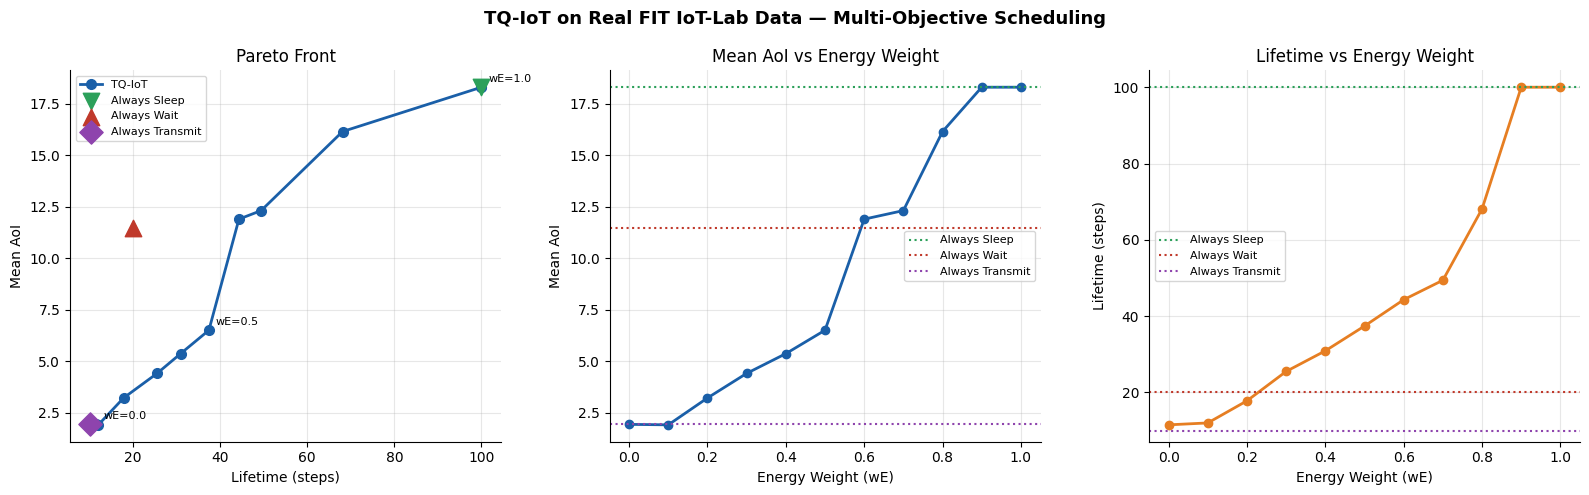

Saved: ../results/pareto_front.png


In [13]:
learned  = df['w_E'].notna()
tqiot_df = df[learned].copy()
base_df  = df[~learned].copy()

bl_colors  = ['#2ca05a', '#c0392b', '#8e44ad']
bl_markers = ['v', '^', 'D']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('TQ-IoT on Real FIT IoT-Lab Data — Multi-Objective Scheduling',
             fontsize=13, fontweight='bold')

# Pareto front
ax = axes[0]
ax.plot(tqiot_df['lifetime'], tqiot_df['mean_aoi'],
        'o-', color='#1a5fa8', lw=2, ms=7, label='TQ-IoT')
for (_, row), col, mk in zip(base_df.iterrows(), bl_colors, bl_markers):
    ax.scatter(row['lifetime'], row['mean_aoi'],
               marker=mk, s=140, color=col, zorder=4, label=row['policy'])
for _, row in tqiot_df.iterrows():
    if row['w_E'] in [0.0, 0.5, 1.0]:
        ax.annotate(f"wE={row['w_E']}", (row['lifetime'], row['mean_aoi']),
                    textcoords='offset points', xytext=(5, 4), fontsize=8)
ax.set_xlabel('Lifetime (steps)')
ax.set_ylabel('Mean AoI')
ax.set_title('Pareto Front')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# AoI vs weight
ax = axes[1]
ax.plot(tqiot_df['w_E'], tqiot_df['mean_aoi'],
        'o-', color='#1a5fa8', lw=2, ms=6)
for (_, row), col in zip(base_df.iterrows(), bl_colors):
    ax.axhline(row['mean_aoi'], color=col, ls=':', lw=1.5, label=row['policy'])
ax.set_xlabel('Energy Weight (wE)')
ax.set_ylabel('Mean AoI')
ax.set_title('Mean AoI vs Energy Weight')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Lifetime vs weight
ax = axes[2]
ax.plot(tqiot_df['w_E'], tqiot_df['lifetime'],
        'o-', color='#e67e22', lw=2, ms=6)
for (_, row), col in zip(base_df.iterrows(), bl_colors):
    ax.axhline(row['lifetime'], color=col, ls=':', lw=1.5, label=row['policy'])
ax.set_xlabel('Energy Weight (wE)')
ax.set_ylabel('Lifetime (steps)')
ax.set_title('Lifetime vs Energy Weight')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("../results/pareto_front.png", dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: ../results/pareto_front.png")


## 13. Exploration Decay

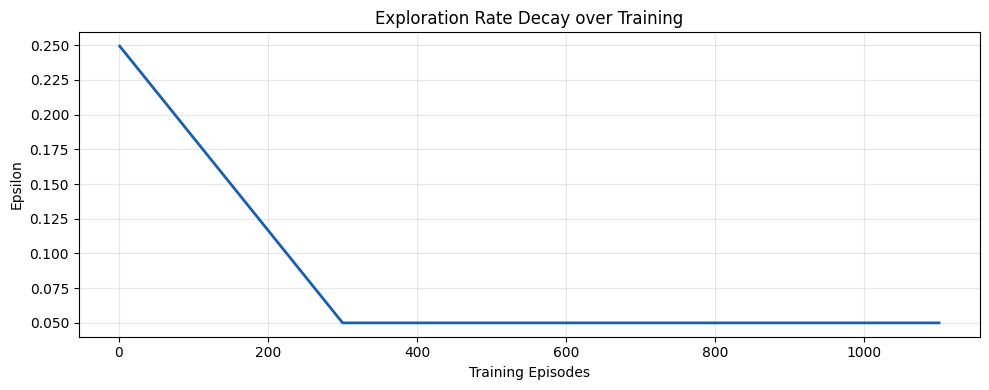

In [14]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(epsilons) + 1), epsilons, lw=2, color='#1a5fa8')
plt.xlabel("Training Episodes")
plt.ylabel("Epsilon")
plt.title("Exploration Rate Decay over Training")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../results/epsilon_decay.png", dpi=150, facecolor='white')
plt.show()


## 14. Cumulative Regret

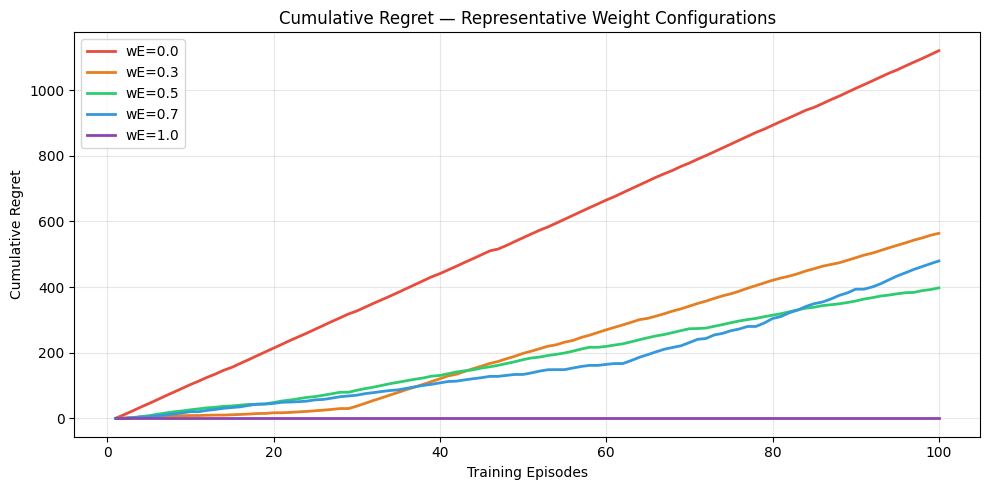

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
rep_colors = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db', '#8e44ad']
rep_labels = ['wE=0.0', 'wE=0.3', 'wE=0.5', 'wE=0.7', 'wE=1.0']
rep_idx    = [0, 3, 5, 7, 10]

for idx, col, lab in zip(rep_idx, rep_colors, rep_labels):
    w       = agent_cfg.weights[idx]
    returns = np.array(sample_eff[w])
    best    = np.maximum.accumulate(returns)
    regret  = np.cumsum(best - returns)
    ax.plot(range(1, len(regret) + 1), regret, lw=2, color=col, label=lab)

ax.set_xlabel("Training Episodes")
ax.set_ylabel("Cumulative Regret")
ax.set_title("Cumulative Regret — Representative Weight Configurations")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../results/cumulative_regret.png", dpi=150, facecolor='white')
plt.show()


## 15. Output Files

| File | Contents |
|---|---|
| `data/processed/fit_iot_clean.csv` | Clean sensor data — one row per (node, step) |
| `results/tq_iot_aoi_results.csv` | Evaluation metrics — 11 TQ-IoT policies + 3 baselines |
| `results/pareto_front.png` | Pareto front, AoI curve, lifetime curve |
| `results/epsilon_decay.png` | Exploration rate decay |
| `results/cumulative_regret.png` | Cumulative regret for 5 policies |
